# DNN + Batch Normalization 图像分类（FashionMNIST）

> 本节在深层神经网络（DNN）的基础上引入 **批归一化（Batch Normalization, BN）** 技术。  
> BN 通过对每个 mini-batch 的激活值进行归一化，能够有效缓解梯度消失/爆炸、加速训练收敛，并在一定程度上起到正则化效果。  
> 论文：*Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift*（Ioffe & Szegedy, 2015）

---

## 一、环境准备与库导入

In [1]:
import matplotlib as mpl          # 导入 matplotlib 绘图库，用于后续学习曲线可视化
import matplotlib.pyplot as plt   # 导入 pyplot 子模块，别名 plt，提供类似 MATLAB 的绘图接口
%matplotlib inline                 
# Jupyter 魔法命令：使图表直接内嵌在 Notebook 输出区，无需手动调用 plt.show()
import numpy as np                 # 导入 numpy 数值计算库，别名 np；提供高效多维数组运算
import sklearn                     # 导入 scikit-learn 机器学习库（此处用于计算分类准确率 accuracy_score）
import pandas as pd                # 导入 pandas 数据分析库，别名 pd；用于整理训练/验证指标记录
import os                          # 导入 os 模块：操作系统接口，用于目录创建、路径拼接等
import sys                         # 导入 sys 模块：访问 Python 运行时信息，如版本号
import time                        # 导入 time 模块（备用），可用于计时
from tqdm import tqdm         # 导入 tqdm 进度条库，auto 模式自动适配 Jupyter/终端环境
import torch                       # 导入 PyTorch 深度学习框架主模块
import torch.nn as nn              # 导入 nn 模块，包含神经网络层（Linear、BatchNorm1d 等）及损失函数
import torch.nn.functional as F    # 导入函数式 API，提供激活函数等无状态操作

print(sys.version_info)                        # 打印 Python 版本信息，确认运行环境
for module in mpl, np, pd, sklearn, torch:    # 遍历主要依赖库列表，依次打印版本
    print(module.__name__, module.__version__) # __name__(str): 库名；__version__(str): 版本号字符串

# 检测 CUDA GPU 是否可用，优先使用 GPU 加速训练
# torch.cuda.is_available() -> bool：有可用 CUDA 设备时返回 True
# torch.device(str) -> torch.device：表示运算设备，'cuda:0' 为第一块 GPU，'cpu' 为 CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)  # 打印当前设备类型，确认训练将运行在哪个硬件上


sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.0+cu132
cuda:0


## 二、加载与预处理 FashionMNIST 数据集

In [2]:
# 计算各数据集的批次数（每个 epoch 中 DataLoader 迭代次数）
# 划分方案：训练集 48000 张（80%），验证集 12000 张（20%），测试集 10000 张
# 批大小(batch_size) = 16
# 结果(float): 每个 epoch 训练批次数 = 48000 / 16 = 3000.0
print("训练集批次数：", 48000 / 16)   # -> 3000.0：每个 epoch 需更新参数 3000 次
print("验证集批次数：", 12000 / 16)   # -> 750.0：每个 epoch 验证 750 个批次
print("测试集批次数：", 10000 / 16)   # -> 625.0：最终评估共 625 个批次

训练集批次数： 3000.0
验证集批次数： 750.0
测试集批次数： 625.0


In [3]:
from torchvision import datasets                   # 从 torchvision 导入数据集模块，包含 FashionMNIST 等标准数据集
from torchvision.transforms import ToTensor        # 导入 ToTensor 变换：将 PIL Image 或 numpy ndarray 转为 FloatTensor，归一化到 [0.0, 1.0]
from torch.utils.data import random_split          # 导入 random_split：按指定长度随机切分 Dataset，返回 Subset 列表

# ── 数据集概览 ─────────────────────────────────────────────────────────────────
# FashionMNIST：10 类服装图像，图像尺寸 28×28（灰度），官方提供 60000 张训练图 + 10000 张测试图
# 划分策略：
#   训练集（train_ds）  ：从官方训练图中取 80%  = 48000 张，用于参数更新
#   验证集（val_ds）    ：从官方训练图中取 20%  = 12000 张，用于超参调优/早停
#   测试集（test_ds）   ：官方测试图全部 10000  张，用于最终模型评估（训练期间不可见）

# 加载官方原始训练集（共 60000 张）
full_train_ds = datasets.FashionMNIST(
    root="data",            # str: 数据集存储根目录，目录不存在时自动创建
    train=True,             # bool: True 表示加载官方训练集（60000 张）
    download=True,          # bool: 本地不存在时自动从网络下载
    transform=ToTensor()    # callable: 将 PIL Image 转为 Tensor，像素值归一化至 [0.0, 1.0]，shape -> [C,H,W]=[1,28,28]
)

# 加载官方测试集（共 10000 张），仅在最终评估时使用
test_ds = datasets.FashionMNIST(
    root="data",            # str: 与训练集共用同一存储目录
    train=False,            # bool: False 表示加载官方测试集（10000 张）
    download=True,          # bool: 若本地不存在则自动下载
    transform=ToTensor()    # callable: 与训练集相同的预处理变换，保证输入格式一致
)

# ── 从训练集中切分出验证集 ────────────────────────────────────────────────────
# random_split(dataset, lengths, generator=None) -> list[Subset]
#   dataset  : 待切分的 Dataset 对象
#   lengths  : list[int]，各子集的样本数量，所有元素之和必须等于 len(dataset)
#   generator: 可选随机数生成器，固定种子可保证每次切分结果相同
# 返回值: [Subset_train, Subset_val]，每个 Subset 持有原始 Dataset 的索引视图

# 计算切分大小：训练集 80%（48000），验证集 20%（12000）
train_size = int(0.8 * len(full_train_ds))   # int: 训练子集大小 = 48000
val_size = len(full_train_ds) - train_size    # int: 验证子集大小 = 12000

train_ds, val_ds = random_split(
    full_train_ds,                                              # Dataset: 原始完整训练集
    [train_size, val_size],                                     # list[int]: 各子集大小 [48000, 12000]
    generator=torch.Generator().manual_seed(42)                 # Generator: 固定随机种子 42，保证切分可复现
)

# 打印各集合大小，便于确认划分结果
print(f"训练集大小：{len(train_ds)}")    # 预期输出：48000
print(f"验证集大小：{len(val_ds)}")      # 预期输出：12000
print(f"测试集大小：{len(test_ds)}")     # 预期输出：10000

# ── 构建 DataLoader ──────────────────────────────────────────────────────────
# DataLoader 将 Dataset 包装为可迭代的批次加载器，每次迭代返回 (inputs, labels) 的 mini-batch

BATCH_SIZE = 16  # int: 全局批大小超参数，统一控制训练/验证/测试批大小

train_loader = torch.utils.data.DataLoader(
    train_ds,               # Dataset: 训练子集（Subset）
    batch_size=BATCH_SIZE,  # int: 每批加载 16 张图；过小训练慢，过大占显存
    shuffle=True            # bool: 每个 epoch 前打乱顺序，防止模型学到样本排列偏差
)
val_loader = torch.utils.data.DataLoader(
    val_ds,                 # Dataset: 验证子集（Subset）
    batch_size=BATCH_SIZE*4,  # int: 验证批大小与训练保持一致（不影响梯度计算）
    shuffle=False           # bool: 验证集不打乱，顺序固定便于结果复现
)
test_loader = torch.utils.data.DataLoader(
    test_ds,                # Dataset: 官方测试集，仅最终评估使用
    batch_size=BATCH_SIZE*4,  # int: 测试批大小与训练保持一致
    shuffle=False           # bool: 测试集不打乱，保证评估结果可复现
)

训练集大小：48000
验证集大小：12000
测试集大小：10000


In [4]:
from torchvision.transforms import Normalize  # 导入 Normalize 变换：对张量按通道做标准化，公式：output = (input - mean) / std

# 计算训练集各通道的均值和标准差（用于后续标准化）
# 参数 ds: Dataset，包含 (img: Tensor[C,H,W], label: int) 的可迭代对象
# 返回值: (mean: Tensor[C], std: Tensor[C])，C 为通道数（灰度图 C=1）
def cal_mean_std(ds):
    mean = 0.          # 累计均值，初始化为 0.0（float）
    std = 0.           # 累计标准差，初始化为 0.0（float）
    for img, _ in ds:  # 遍历数据集，img: Tensor[C,H,W]；_ 表示忽略标签
        mean += img.mean(dim=(1, 2))  # 对 H、W 维度取均值，得到每个通道的均值；累加，返回 Tensor[C]
        std += img.std(dim=(1, 2))    # 对 H、W 维度取标准差；累加，返回 Tensor[C]
    mean /= len(ds)    # 除以样本总数，得到数据集级别的通道均值；len(ds) 返回 int（样本数）
    std /= len(ds)     # 除以样本总数，得到数据集级别的通道标准差
    return mean, std   # 返回 (Tensor[C], Tensor[C])，灰度图为 (Tensor[1], Tensor[1])

mean, std = cal_mean_std(train_ds)  # 计算训练集各通道的均值和标准差，返回 Tensor 类型（灰度图为 shape: [1]）
mean = mean.item()  # 将 Tensor 转换为纯浮点数（float），方便后续作为 Normalize 的参数
std = std.item()    # 同理，将 Tensor 转为 float 类型（对应单通道）
print(mean,std)

# 定义归一化预处理序列，将原始像素（经 ToTensor 后在 [0,1]）标准化到近似 N(0,1) 分布
# nn.Sequential 将多个 Module 串联，按顺序对输入进行处理
transforms = nn.Sequential(
    Normalize([mean], [std])  # Normalize(mean: list[float], std: list[float])
                                    # mean≈[0.2860]: 灰度通道的均值；std≈[0.3205]: 标准差
                                    # 标准化公式：x = (x - 0.2860) / 0.3205
                                    # 目的：让输入分布接近标准正态分布，有助于梯度稳定传播
)


0.28570792078971863 0.32025304436683655


## 三、定义模型
xavier初始化出自论文 《Understanding the difficulty of training deep feedforward neural networks》，适用于使用`tanh`和`sigmoid`激活函数的方法。但是采用的是`relu`激活函数，采用He初始化（何凯明初始化）会更加合适

He初始化出自论文 《Delving deep into rectifiers: Surpassing human-level performance on ImageNet classification》

In [5]:
class NeuralNetwork(nn.Module):
    """带 Batch Normalization 的深层全连接神经网络（DNN + BN）。

    核心改进：在每个线性层之后、激活函数之前插入 BatchNorm1d。
    批归一化（BN）在每个 mini-batch 上将激活值归一化到均值为 0、方差为 1，
    然后通过可学习参数 gamma（weight）和 beta（bias）进行缩放与平移，
    从而减少内部协变量偏移（Internal Covariate Shift），加速训练收敛。
    论文：《Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift》
    """

    def __init__(self, layers_num=2):
        # layers_num (int): 网络总层数（含输入层），默认为 2（即 1 个隐藏层 + 1 个输出层）
        super().__init__()          # 调用父类 nn.Module 的初始化方法，必须在子类 __init__ 最先调用
        self.transforms = transforms  # 保存预处理变换（Normalize），在 forward 中对输入做标准化
        self.flatten = nn.Flatten()   # nn.Flatten(): 将多维张量展平为二维 [batch_size, -1]
                                      # 输入 [B,1,28,28] → 输出 [B,784]

        # 构建第一个隐藏层：Linear → BatchNorm1d → ReLU
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 100),
            # nn.Linear(in_features=784, out_features=100):
            #   将展平后的图像特征向量（784 维）映射到隐藏层（100 维）
            #   weight: Tensor[100, 784]；bias: Tensor[100]
            #   输出 shape: [B, 100]

            # 注意：标准做法是 先 BatchNorm 再 激活函数（BN 在激活前对线性输出做归一化效果最好）
            # 参见论文 《Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift》
            nn.BatchNorm1d(100),
            # nn.BatchNorm1d(num_features=100):
            #   对形状 [B, 100] 的输入做批归一化
            #   num_features (int): 特征维度，等于上一层输出维度
            #   可学习参数：weight(gamma) Tensor[100]，bias(beta) Tensor[100]
            #   训练时使用当前 batch 的均值/方差；推理时使用训练期间的运行均值/方差
            #   输出 shape: [B, 100]，分布接近 N(0,1) 再经 gamma/beta 缩放平移
            nn.ReLU(),
            # nn.ReLU(): 修正线性单元激活函数，公式：f(x) = max(0, x)
            # 引入非线性；负值置零，正值不变；输出 shape 不变 [B, 100]
        )

        # 动态添加 (layers_num - 1) 个隐藏层，每层结构：Linear → BatchNorm1d → ReLU
        for i in range(1, layers_num):
            self.linear_relu_stack.add_module(f"Linear_{i}", nn.Linear(100, 100))
            # add_module(name: str, module: nn.Module): 向 Sequential 末尾动态追加子模块
            # nn.Linear(100, 100): 隐藏层之间维度保持不变 [B,100] → [B,100]

            self.linear_relu_stack.add_module(f"batchnorm_{i}", nn.BatchNorm1d(100))
            # 因为隐藏层特征是 1 维向量（非图像），所以使用 BatchNorm1d 而非 BatchNorm2d
            # num_features=100 对应上一层 Linear 的输出维度

            self.linear_relu_stack.add_module(f"relu", nn.ReLU())
            # 每层结构：线性变换 → 批归一化 → 激活，是加入 BN 的标准模式

        # 添加输出层：将隐藏层特征映射到 10 个类别的 logits（未经 softmax）
        self.linear_relu_stack.add_module("Output Layer", nn.Linear(100, 10))
        # nn.Linear(100, 10): in_features=100，out_features=10（FashionMNIST 有 10 类）
        # 输出 shape: [B, 10]；logits 值域为 (-∞, +∞)，后续由 CrossEntropyLoss 内部处理 softmax

        self.init_weights()  # 调用权重初始化方法，对所有 Linear 层做 He 初始化

    def init_weights(self):
        """使用 He（Kaiming）均匀分布初始化全连接层的权重，将偏置初始化为零。

        He 初始化：weight ~ Uniform(-bound, bound)，bound = sqrt(6 / ((1 + a^2) * fan_in))
        其中 a 为 LeakyReLU 的负斜率（ReLU 时 a=0），mode='fan_in' 保持前向传播时方差不变。
        目的：专为 ReLU/LeakyReLU 激活函数设计，弥补 ReLU 将负半轴置零导致的方差减半问题，
              相比 Xavier 初始化更适合深层 ReLU 网络，有效缓解梯度消失/爆炸。
        """
        for m in self.modules():            # 遍历模型中所有子模块（递归）；m: nn.Module
            if isinstance(m, nn.Linear):    # 仅对全连接层（nn.Linear）做特殊初始化
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                # kaiming_uniform_(tensor, nonlinearity): 就地用 He 均匀分布填充权重
                # nonlinearity='relu'(str): 指定激活函数类型，用于计算推荐的 gain 值
                # m.weight: Tensor[out_features, in_features]
                nn.init.zeros_(m.bias)
                # zeros_(tensor): 就地将偏置初始化为全零
                # m.bias: Tensor[out_features]

    def forward(self, x):
        """前向传播，定义输入张量从输入到输出的计算流程。

        参数:
            x (Tensor): 输入图像批次，shape [B, 1, 28, 28]
                B: batch size；1: 灰度通道；28×28: 图像尺寸

        返回:
            logits (Tensor): 各类别的原始得分，shape [B, 10]
        """
        # x.shape [B, 1, 28, 28]
        x = self.transforms(x)   # 标准化：对输入图像做 Normalize，去除均值、除以标准差
                                  # 输出 shape 不变：[B, 1, 28, 28]
        x = self.flatten(x)       # 展平：将 [B, 1, 28, 28] → [B, 784]，消除空间维度
        # 展平后 x.shape [B, 784]
        logits = self.linear_relu_stack(x)
        # 通过 Sequential 堆栈（Linear→BN→ReLU 重复多次 → Linear）做特征变换
        # logits.shape [B, 10]
        return logits             # 返回 logits Tensor[B, 10]，每行对应一个样本的 10 类得分

# 打印模型各层参数名及参数量，验证网络结构
print(f"{'layer_name':^40}\tparamerters num")
total_params = 0
for idx, (key, value) in enumerate(NeuralNetwork(20).named_parameters()):
    # named_parameters() -> Iterator[(str, Tensor)]: 递归返回模型所有可学习参数的 (名称, 张量) 对
    # key (str): 参数名（如 'linear_relu_stack.0.weight'）
    # value (Tensor): 参数张量；np.prod(value.shape) 计算该参数的元素总数
    print("{}{:<40}\t{:^10}".format(idx, key, np.prod(value.shape)))
    total_params += np.prod(value.shape)  # 累加参数量
total_params  # 最终输出模型总参数量（int）

               layer_name               	paramerters num
0linear_relu_stack.0.weight              	  78400   
1linear_relu_stack.0.bias                	   100    
2linear_relu_stack.1.weight              	   100    
3linear_relu_stack.1.bias                	   100    
4linear_relu_stack.Linear_1.weight       	  10000   
5linear_relu_stack.Linear_1.bias         	   100    
6linear_relu_stack.batchnorm_1.weight    	   100    
7linear_relu_stack.batchnorm_1.bias      	   100    
8linear_relu_stack.Linear_2.weight       	  10000   
9linear_relu_stack.Linear_2.bias         	   100    
10linear_relu_stack.batchnorm_2.weight    	   100    
11linear_relu_stack.batchnorm_2.bias      	   100    
12linear_relu_stack.Linear_3.weight       	  10000   
13linear_relu_stack.Linear_3.bias         	   100    
14linear_relu_stack.batchnorm_3.weight    	   100    
15linear_relu_stack.batchnorm_3.bias      	   100    
16linear_relu_stack.Linear_4.weight       	  10000   
17linear_relu_stack.Linear_4.bias  

np.int64(275410)

## 四、模型训练

### 4.1 评估函数定义

In [6]:
from sklearn.metrics import accuracy_score  # 导入 accuracy_score：计算分类准确率，返回正确预测占总样本的比例（float）

# @torch.no_grad() 装饰器：在此函数执行期间禁用梯度计算
# 评估时不需要反向传播，禁用梯度可节省显存并加快计算速度
@torch.no_grad()
def evaluating(model, dataloader, loss_fct):
    """在给定数据集上评估模型的损失和准确率。

    参数:
        model (nn.Module): 待评估的神经网络模型
        dataloader (DataLoader): 封装了验证/测试数据集的批次加载器
        loss_fct (nn.Module): 损失函数（如 CrossEntropyLoss）

    返回:
        (float, float): (平均损失, 准确率)
            平均损失：所有批次 loss 的算术平均值
            准确率：预测正确的样本占总样本的比例，范围 [0, 1]
    """
    loss_list = []    # list[float]: 存储每个批次的损失值
    pred_list = []    # list[int]: 存储所有样本的预测类别标签
    label_list = []   # list[int]: 存储所有样本的真实类别标签
    model.eval()  # 切换到评估模式（禁用 BN/Dropout 等训练特有行为）
    for datas, labels in dataloader:      # 遍历 dataloader，每次取一个批次
        datas = datas.to(device)          # 将输入图像张量移到指定设备（GPU/CPU）；datas: Tensor[B,1,28,28]
        labels = labels.to(device)        # 将标签张量移到指定设备；labels: Tensor[B]，值为 0-9 的类别索引

        # 前向计算（无梯度）
        logits = model(datas)             # 调用模型前向传播，返回 logits: Tensor[B, 10]
        loss = loss_fct(logits, labels)   # 计算当前批次的交叉熵损失；loss: 标量 Tensor（0-d）
        loss_list.append(loss.item())     # .item() 将 0-d Tensor 转为 Python float，存入列表

        preds = logits.argmax(axis=-1)    # 沿最后一维（类别维）取最大值索引作为预测类别
                                          # argmax(axis=-1): 返回每个样本概率最大的类别索引；preds: Tensor[B]
        pred_list.extend(preds.cpu().numpy().tolist())
        # .cpu(): 将张量从 GPU 移回 CPU（若已在 CPU 则无操作）
        # .numpy(): Tensor 转 numpy ndarray
        # .tolist(): ndarray 转 Python list，方便与 sklearn 接口对接
        # extend: 将当前批次的预测追加到总列表中
        label_list.extend(labels.cpu().numpy().tolist())  # 同理，将真实标签追加到列表

    acc = accuracy_score(label_list, pred_list)
    # accuracy_score(y_true: list, y_pred: list) -> float
    # 计算整体准确率 = 预测正确样本数 / 总样本数
    return np.mean(loss_list), acc
    # np.mean(loss_list) -> float: 所有批次损失的平均值（注意：每批样本数相同时此方式等价于全局均值）
    # acc -> float: 分类准确率，范围 [0.0, 1.0]


### 4.2 训练辅助回调类（TensorBoard / 保存 Checkpoint / 早停）

In [7]:
from torch.utils.tensorboard import SummaryWriter  # 导入 TensorBoard 日志写入器，用于可视化训练指标


class TensorBoardCallback:
    """TensorBoard 可视化回调类。

    在每个评估步骤将训练损失、验证损失、准确率、学习率等指标写入 TensorBoard 日志，
    方便通过 `tensorboard --logdir runs` 命令在浏览器中查看训练曲线。
    """

    def __init__(self, log_dir, flush_secs=10):
        """初始化 TensorBoard 日志写入器。

        参数:
            log_dir (str): TensorBoard 日志文件的存储目录（如 'runs/bn'）
            flush_secs (int): 每隔多少秒将缓冲区内容写入磁盘，默认 10 秒
        """
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)
        # SummaryWriter: TensorBoard 核心对象，负责将各类数据序列化为 tfevents 文件

    def draw_model(self, model, input_shape):
        """将模型计算图写入 TensorBoard，可在 GRAPHS 面板中查看网络结构。

        参数:
            model (nn.Module): 要可视化的神经网络模型
            input_shape (list): 输入张量的形状（不含 batch 维），如 [1, 28, 28]
        """
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))
        # add_graph: 通过一次前向传播自动追踪计算图并写入日志
        # torch.randn(input_shape): 生成符合 N(0,1) 的随机输入张量，用于追踪

    def add_loss_scalars(self, step, loss, val_loss):
        """将训练损失和验证损失写入 TensorBoard。

        参数:
            step (int): 当前全局步数，作为横坐标
            loss (float): 当前批次的训练损失
            val_loss (float): 当前评估步骤的验证损失
        """
        self.writer.add_scalars(
            main_tag="training/loss",                              # str: TensorBoard 中显示的图表名称
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},  # dict[str, float]: 在同一图表中叠加多条曲线
            global_step=step,                                       # int: 横坐标（全局步数）
        )

    def add_acc_scalars(self, step, acc, val_acc):
        """将训练准确率和验证准确率写入 TensorBoard。

        参数:
            step (int): 当前全局步数
            acc (float): 当前批次的训练准确率，范围 [0, 1]
            val_acc (float): 当前评估步骤的验证准确率，范围 [0, 1]
        """
        self.writer.add_scalars(
            main_tag="training/accuracy",
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},
            global_step=step,
        )

    def add_lr_scalars(self, step, learning_rate):
        """将当前学习率写入 TensorBoard。

        参数:
            step (int): 当前全局步数
            learning_rate (float): 当前优化器的学习率
        """
        self.writer.add_scalars(
            main_tag="training/learning_rate",
            tag_scalar_dict={"learning_rate": learning_rate},
            global_step=step,
        )

    def __call__(self, step, **kwargs):
        """使实例可像函数一样调用，根据传入的关键字参数选择性地写入各类指标。

        参数:
            step (int): 当前全局步数
            **kwargs: 可选关键字参数，支持 loss、val_loss、acc、val_acc、lr
        """
        # 从 kwargs 中弹出损失值（pop 取出后从字典删除，避免重复处理）
        loss = kwargs.pop("loss", None)        # float 或 None：训练损失
        val_loss = kwargs.pop("val_loss", None)  # float 或 None：验证损失
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)  # 同时有训练和验证损失时才写入（保持曲线对齐）

        # 从 kwargs 中弹出准确率值
        acc = kwargs.pop("acc", None)          # float 或 None：训练准确率
        val_acc = kwargs.pop("val_acc", None)  # float 或 None：验证准确率
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc)

        # 从 kwargs 中弹出学习率
        learning_rate = kwargs.pop("lr", None)  # float 或 None：当前学习率
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate)


In [8]:
class SaveCheckpointsCallback:
    """模型 Checkpoint 保存回调类。

    按固定步数间隔评估并保存模型权重。支持"仅保存最佳"和"每步保存"两种模式。
    通常在深度学习训练中按 step（而非 epoch）触发保存，更灵活。
    """

    def __init__(self, save_dir, save_step=5000, save_best_only=True):
        """初始化 Checkpoint 保存器。

        参数:
            save_dir (str): checkpoint 文件的存储目录（如 'checkpoints/bn'）
            save_step (int): 每隔多少 step 触发一次保存检查，默认 5000
            save_best_only (bool): True 时仅保留验证指标最优的模型；False 时每次触发都保存
        """
        self.save_dir = save_dir          # str: 保存目录路径
        self.save_step = save_step        # int: 保存触发间隔（以 global_step 为单位）
        self.save_best_only = save_best_only  # bool: 是否只保存最优模型
        self.best_metrics = -1            # float: 当前记录的最优验证指标，初始化为 -1（任何正值都优于初始值）

        # 若保存目录不存在则创建（makedirs 可递归创建多级目录）
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)    # makedirs(path): 递归创建路径中所有不存在的目录

    def __call__(self, step, state_dict, metric=None):
        """每个 step 调用一次，根据条件决定是否保存 checkpoint。

        参数:
            step (int): 当前全局步数
            state_dict (dict): 模型的状态字典（包含所有可学习参数的张量）
            metric (float, optional): 用于判断是否为最优的验证指标（如 val_acc）
        """
        if step % self.save_step > 0:    # 仅在 step 为 save_step 整数倍时触发（step=0 时也会触发）
            return                        # 不满足条件则直接跳过

        if self.save_best_only:
            assert metric is not None     # 仅保存最优模式下，metric 不能为 None
            if metric >= self.best_metrics:  # 当前指标优于历史最优时才保存
                torch.save(state_dict, os.path.join(self.save_dir, "relu+he+bn_best.ckpt"))
                # torch.save(obj, f): 将对象序列化（pickle）保存到文件
                # state_dict: dict[str, Tensor]，键为参数名，值为参数张量
                # os.path.join: 拼接目录与文件名，生成完整路径字符串
                self.best_metrics = metric  # 更新最优指标记录
        else:
            torch.save(state_dict, os.path.join(self.save_dir, f"relu+he+bn_{step}.ckpt"))
            # 非"仅最优"模式：以 step 编号为文件名保存每个 checkpoint



In [9]:
class EarlyStopCallback:
    """早停回调类（Early Stopping）。

    当验证指标在连续 patience 次评估中均未提升超过 min_delta 时，发出停止训练的信号。
    早停是防止过拟合的重要技术：当模型在验证集上不再改善时及时停止，避免继续在训练集上过拟合。
    """

    def __init__(self, patience=5, min_delta=0.01):
        """初始化早停回调。

        参数:
            patience (int): 允许连续无改善的评估次数，超过后触发早停，默认 5
                较大的 patience 让模型有更多机会走出平台期，但可能浪费时间
            min_delta (float): 指标提升的最小阈值，低于此值视为"无改善"，默认 0.01
                防止因微小波动（如 0.0001 的提升）而一直不触发早停
        """
        self.patience = patience        # int: 容忍连续无改善的次数
        self.min_delta = min_delta      # float: 判定为"有效提升"的最小变化量
        self.best_metric = -1           # float: 历史最优指标值，初始化为 -1
        self.counter = 0                # int: 当前连续无改善的次数计数器

    def __call__(self, metric):
        """每次评估后调用，根据当前指标决定是否重置或递增计数器。

        参数:
            metric (float): 当前评估步骤的验证指标值（如 val_acc），范围 [0, 1]
        """
        if metric >= self.best_metric + self.min_delta:
            # 当前指标比历史最优提升了至少 min_delta，视为有效改善
            self.best_metric = metric   # 更新最优指标记录
            self.counter = 0            # 重置无改善计数器
        else:
            self.counter += 1           # 无明显改善，计数器加 1

    @property
    def early_stop(self):
        """只读属性：判断是否应触发早停。

        返回:
            bool: True 表示应立即停止训练；False 表示继续训练
        """
        return self.counter >= self.patience  # 连续无改善次数达到 patience 时返回 True


### 4.3 训练函数定义与训练过程

In [10]:
def training(
    model,            # nn.Module: 待训练的神经网络模型
    train_loader,     # DataLoader: 训练集批次加载器
    val_loader,       # DataLoader: 验证集批次加载器
    epoch,            # int: 最大训练轮数（每轮遍历一次完整训练集）
    loss_fct,         # nn.Module: 损失函数（如 CrossEntropyLoss）
    optimizer,        # torch.optim.Optimizer: 优化器（如 SGD、Adam）
    tensorboard_callback=None,   # TensorBoardCallback 或 None：TensorBoard 可视化回调
    save_ckpt_callback=None,     # SaveCheckpointsCallback 或 None：Checkpoint 保存回调
    early_stop_callback=None,    # EarlyStopCallback 或 None：早停回调
    eval_step=500,    # int: 每隔多少 step 进行一次验证评估，默认 500
):
    """完整的训练循环，支持 TensorBoard 可视化、Checkpoint 保存和早停。

    返回:
        record_dict (dict): 训练过程记录，格式为
            {'train': [{'loss': float, 'acc': float, 'step': int}, ...],
             'val':   [{'loss': float, 'acc': float, 'step': int}, ...]}
    """
    record_dict = {
        "train": [],   # list[dict]: 每个训练 step 的损失和准确率记录
        "val": []      # list[dict]: 每次评估时的验证损失和准确率记录
    }

    global_step = 0     # int: 全局步数计数器，跨 epoch 累积（每处理一个 batch 加 1）
    model.train()       # 将模型设为训练模式：启用 BatchNorm 的 batch 统计、启用 Dropout
    with tqdm(total=epoch * len(train_loader)) as pbar:
        # tqdm(total=N): 创建进度条，total 为总步数 = epoch × 每epoch批次数
        for epoch_id in range(epoch):       # 遍历每个 epoch（从 0 到 epoch-1）
            for datas, labels in train_loader:  # 遍历训练集每个批次
                datas = datas.to(device)         # 将输入图像张量移至指定设备；shape [B,1,28,28]
                labels = labels.to(device)       # 将标签张量移至指定设备；shape [B]

                # ① 梯度清空：必须在每次反向传播前清零，防止梯度累积
                optimizer.zero_grad()

                # ② 前向传播：将输入送入模型，得到预测 logits
                logits = model(datas)            # Tensor[B, 10]

                # ③ 计算损失：CrossEntropyLoss 内含 log_softmax + NLLLoss
                loss = loss_fct(logits, labels)  # Tensor (0-d 标量)

                # ④ 反向传播：自动计算损失对所有可学习参数的梯度
                loss.backward()

                # ⑤ 参数更新：优化器根据梯度和学习率更新模型参数
                optimizer.step()

                preds = logits.argmax(axis=-1)   # 取 logits 最大值的索引作为预测类别；Tensor[B]

                acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())
                # 计算当前批次的训练准确率（float），先移至 CPU 再转 numpy
                loss = loss.cpu().item()         # 将 0-d Tensor 转为 Python float

                # 记录当前 step 的训练指标
                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step
                })

                # 每隔 eval_step 个 step 进行一次验证评估
                if global_step % eval_step == 0:
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)
                    # evaluating 返回 (float, float): (验证损失均值, 验证准确率)
                    record_dict["val"].append({
                        "loss": val_loss, "acc": val_acc, "step": global_step
                    })
                    model.train()  # 评估完成后切回训练模式

                    # 1. 写入 TensorBoard 可视化日志
                    if tensorboard_callback is not None:
                        tensorboard_callback(
                            global_step,
                            loss=loss, val_loss=val_loss,
                            acc=acc, val_acc=val_acc,
                            lr=optimizer.param_groups[0]["lr"],
                            # param_groups[0]["lr"]: 获取优化器第一个参数组的当前学习率（float）
                        )

                    # 2. 保存模型 Checkpoint
                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)
                        # model.state_dict() -> dict[str, Tensor]: 返回包含所有可学习参数的状态字典

                    # 3. 检查是否触发早停
                    if early_stop_callback is not None:
                        early_stop_callback(val_acc)         # 传入当前验证准确率，更新早停计数器
                        if early_stop_callback.early_stop:   # 若连续无改善次数 >= patience
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict               # 提前返回，终止训练

                global_step += 1        # 全局步数加 1
                pbar.update(1)          # 进度条前进 1 步
                pbar.set_postfix({"epoch": epoch_id})  # 在进度条后缀显示当前 epoch 编号

    return record_dict  # 训练正常结束，返回完整记录字典


epoch = 50   # int: 最大训练轮数，实际因早停可能提前结束

# 注：层数过多（如 20 层）在没有 BN 时难以训练（梯度消失），加了 BN 后可以适当加深
# 这里使用 10 层进行实验
model = NeuralNetwork(layers_num=10)   # 创建含 BN 的 10 层 DNN 模型

# 1. 定义损失函数：采用交叉熵损失（适用于多分类任务）


In [11]:
loss_fct = nn.CrossEntropyLoss()
# nn.CrossEntropyLoss(): 交叉熵损失函数，专为多分类任务设计
# 内部等价于：log_softmax(logits) + NLLLoss（负对数似然损失）
# 输入 logits: Tensor[B, num_classes]（原始未归一化得分）
# 输入 labels: Tensor[B]（类别索引，long 类型，值在 [0, num_classes-1]）
# 返回: 标量 Tensor（当前 batch 的平均交叉熵损失）
# 公式：L = -log(exp(logit[y]) / Σexp(logit[k]))，y 为真实类别

In [12]:
# 2. 定义优化器：采用 Adam（自适应矩估计）优化器
# 由于网络使用了 BatchNorm（BN），激活值分布更稳定，梯度方差更小，
# 可以使用比 SGD 更大的学习率（此处设为 0.01，SGD 常用 0.001）
optimizer = torch.optim.Adam(
    model.parameters(),  # 传入模型所有可学习参数，返回 Generator[Tensor]
    lr=0.01,             # float: 学习率，Adam + BN 组合下可适当调大，此处为 0.01
    betas=(0.9, 0.999),  # Tuple[float, float]: 一阶/二阶矩估计的指数衰减率，默认值即可
    eps=1e-8             # float: 数值稳定性小量，防止除以零，默认 1e-8
)
# Adam 更新公式：m = beta1*m + (1-beta1)*g；v = beta2*v + (1-beta2)*g^2
# param -= lr * m_hat / (sqrt(v_hat) + eps)，其中 m_hat/v_hat 为偏差修正后的估计值

# 1. 创建 TensorBoard 可视化回调，日志保存到目录
tensorboard_callback = TensorBoardCallback(os.path.join("tensorboard_logs", "relu+he+bn"))
# 可通过命令行 `tensorboard --logdir runs` 启动可视化服务器
tensorboard_callback.draw_model(model, [1, 28, 28])
# 将模型计算图写入日志，input_shape=[1,28,28]（单张灰度图的 shape）

# 2. 创建 Checkpoint 保存回调：每个 eval_step 检查，只保存验证准确率最高的模型
save_ckpt_callback = SaveCheckpointsCallback(os.path.join("model_checkpoints", "relu+he+bn"), save_best_only=True)

# 3. 创建早停回调：连续 5 次评估无提升（提升幅度 < 0.001）则停止训练
early_stop_callback = EarlyStopCallback(patience=5, min_delta=0.001)
# patience=5: 容忍 5 次评估无改善；min_delta=0.001: 提升不足 0.1% 视为无改善

model = model.to(device)
# 将模型（包括所有参数和 BatchNorm 运行均值/方差）移至指定设备（GPU 或 CPU）
# 返回: nn.Module（就地修改并返回自身）

In [13]:
# 启动训练，传入所有配置参数，返回训练记录字典
record = training(
    model,                                     # nn.Module: 待训练的模型（已移至 device）
    train_loader,                              # DataLoader: 训练集加载器
    val_loader,                                # DataLoader: 验证集加载器
    epoch,                                     # int: 最大训练轮数（50 轮）
    loss_fct,                                  # nn.CrossEntropyLoss: 损失函数
    optimizer,                                 # Adam 优化器
    tensorboard_callback=tensorboard_callback, # TensorBoard 回调（可视化）
    save_ckpt_callback=save_ckpt_callback,     # Checkpoint 保存回调
    early_stop_callback=early_stop_callback,   # 早停回调
    eval_step=len(train_loader)                # 每个 epoch 结束时评估一次（len(train_loader)=3000 steps/epoch）
)
# record -> dict: {'train': [...], 'val': [...]}，包含完整训练/验证曲线数据

 40%|████      | 60000/150000 [07:19<10:58, 136.61it/s, epoch=19]

Early stop at epoch 20 / global_step 60000


### 4.4 可视化学习曲线

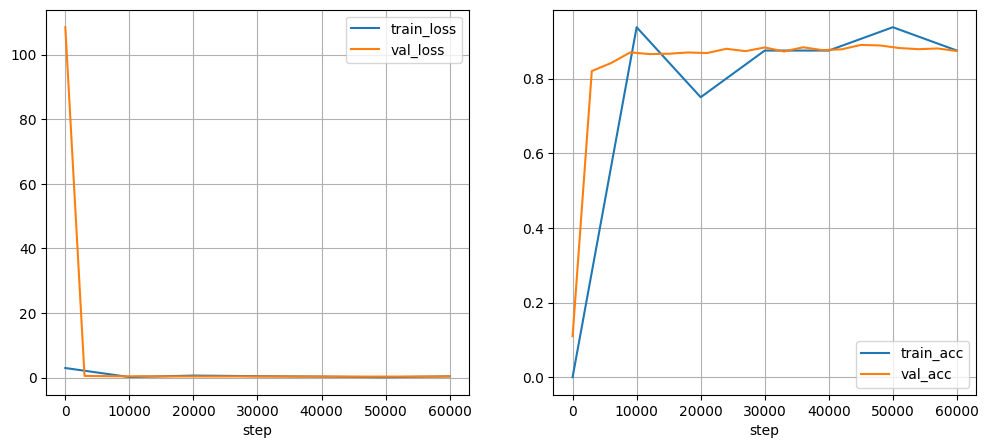

In [14]:
# 注意：损失值（loss）不一定在 [0, 1] 范围内，纵轴不要固定范围
def plot_learning_curves(record_dict, sample_step=500):
    """绘制训练损失、准确率的学习曲线，同时展示训练集和验证集的对比。

    参数:
        record_dict (dict): training() 返回的记录字典，包含 'train' 和 'val' 两个键
        sample_step (int): 从训练记录中每隔多少步取一个点绘图（降采样防止图像过密），默认 500
    """
    # 将训练记录列表转为 DataFrame，以 step 为索引，每隔 sample_step 取样
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    # pd.DataFrame(list[dict]) -> DataFrame: 将记录列表转换为表格
    # .set_index("step"): 将 step 列设为行索引，便于以步数为横坐标绘图
    # .iloc[::sample_step]: 每隔 sample_step 行取一行，降低训练曲线密度

    val_df = pd.DataFrame(record_dict["val"]).set_index("step")
    # 验证集记录量少（每个 eval_step 才一条），不需要降采样

    # 根据指标数量决定子图列数（loss 和 acc 各一列，共 2 列）
    fig_num = len(train_df.columns)   # int: 指标数量（columns 为 ['loss', 'acc']，共 2 个）
    fig, axs = plt.subplots(1, fig_num, figsize=(6 * fig_num, 5))
    # plt.subplots(nrows, ncols, figsize): 创建子图网格
    # figsize=(宽, 高)，单位英寸；这里每列宽 6 英寸，高 5 英寸

    for idx, item in enumerate(train_df.columns):  # 遍历每个指标（'loss', 'acc'）
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")
        # plot(x, y, label): 绘制训练曲线；x 为步数（int），y 为指标值（float）
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")
        # 在同一子图叠加验证曲线
        axs[idx].grid()           # 添加网格线，便于读数
        axs[idx].legend()         # 显示图例（train_xxx / val_xxx）
        axs[idx].set_xlabel("step")  # 设置横轴标签为"step"（全局步数）

    plt.show()  # 显示图表（在 %matplotlib inline 模式下也可省略，但显式调用更清晰）

plot_learning_curves(record, sample_step=10000)  # 横坐标是全局步数（global step），每隔 10000 步取一个训练点

## 五、实验评估与总结

### 5.1 加载最佳 Checkpoint 并最终评估

In [15]:
model = model.to(device)   # 确保模型在正确设备上（若已经在 device 则此操作无额外开销）

# 加载训练过程中保存的最优 Checkpoint
model.load_state_dict(
    torch.load(
        os.path.join("model_checkpoints","relu+he+bn","relu+he+bn_best.ckpt"),  # str: checkpoint 文件路径（由 SaveCheckpointsCallback 保存的最优权重）
        weights_only=True,           # bool: True 表示仅加载权重张量，忽略其他 Python 对象（更安全，PyTorch 2.x 推荐）
        map_location="cpu"           # str 或 device: 将保存时的设备张量重新映射到 CPU 加载，避免 GPU/CPU 设备不匹配错误
    )
)
# load_state_dict(dict): 将加载的状态字典中的权重赋给模型对应参数（就地修改）

model.eval()   # 切换为评估模式：BatchNorm 使用训练期间积累的运行均值/方差（而非当前 batch 的统计量）

# 在验证集（测试集）上计算最终性能指标
loss, acc = evaluating(model, val_loader, loss_fct)
# evaluating 返回 (float, float): (平均损失, 准确率)
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")
# :.4f 表示保留 4 位小数输出，方便与其他模型比较

loss:     0.3206
accuracy: 0.8901
